# Gráfico de linhas no Matplotlib — várias séries no mesmo gráfico

O `plt.plot` não desenha **só uma linha**. Se você chamar a função de novo, a nova linha entra no **mesmo gráfico**. É assim que se compara duas ou mais séries de uma vez.

Este exemplo vem do capítulo *An Introduction to Statistical Learning*, e mostra o **trade-off Viés-Variância**: por que existe um ponto ideal de complexidade para um modelo de Machine Learning.

In [1]:
%matplotlib inline

from matplotlib import pyplot as plt

## 1. O import

`pyplot` é o módulo que cuida de **desenhar**. O `as plt` cria um **apelido**: em vez de digitar `pyplot.plot(...)`, você digita só `plt.plot(...)`.

## 2. Os dados

Cada lista guarda uma série de valores. As duas primeiras andam em **direções opostas**:

In [2]:
variance = [1, 2, 4, 8, 16, 32, 64, 128, 256]      # sobe
bias_squared = [256, 128, 64, 32, 16, 8, 4, 2, 1]   # desce

| `xs` | `variance` | `bias_squared` | `total_error` |
| --- | --- | --- | --- |
| 0 | 1 | 256 | 257 |
| 1 | 2 | 128 | 130 |
| 2 | 4 | 64 | 68 |
| 3 | 8 | 32 | 40 |
| 4 | 16 | 16 | **32** ← mínimo |
| 5 | 32 | 8 | 40 |
| 6 | 64 | 4 | 68 |
| 7 | 128 | 2 | 130 |
| 8 | 256 | 1 | 257 |

Repare que os dois lados são **simétricos e espelhados**.

## 3. `total_error` — somando lista com lista

```python
total_error = [x + y for x, y in zip(variance, bias_squared)]
```

- `zip()` = "zíper": junta as duas listas **par a par** → `(1, 256)`, `(2, 128)`, `(4, 64)`...
- `x + y` = soma os dois números de cada par.
- `[... for ...]` é uma **list comprehension**: um `for` que já monta a lista nova pronta.

> ⚠️ O detalhe crucial: `zip` **devolve o menor comprimento** se as listas tiverem tamanhos diferentes. Se `bias_squared` tivesse só 3 elementos, você receberia só 3 erros, **sem nenhum aviso**.

In [3]:
total_error = [x + y for x, y in zip(variance, bias_squared)]

print(total_error)

[257, 130, 68, 40, 32, 40, 68, 130, 257]


## 4. `xs` — o eixo horizontal

```python
xs = [i for i, _ in enumerate(variance)]
```

`enumerate()` caminha pela lista devolvendo **pares** (posição, valor): `(0, 1)`, `(1, 2)`, `(2, 4)`...

- `i` = a posição (0 até 8)
- `_` = o valor. O `_` é uma **convenção para "esse eu não uso"** — funciona porque o Python aceita qualquer nome como variável, e `_` simplesmente não é lido em lugar nenhum.

O resultado é só uma sequência de posições: `[0, 1, 2, 3, 4, 5, 6, 7, 8]`. Serve para o Matplotlib ter **onde encaixar os pontos**.

In [4]:
xs = [i for i, _ in enumerate(variance)]

print(xs)
print("erro mínimo:", min(total_error), "em xs =", total_error.index(min(total_error)))

[0, 1, 2, 3, 4, 5, 6, 7, 8]
erro mínimo: 32 em xs = 4


## 5. Três linhas, um gráfico só

Cada `plt.plot` desenha **uma linha só**. Para juntar várias no mesmo gráfico, é só **chamar a função de novo**: o Matplotlib guarda o "gráfico atual" em memória e a segunda chamada é somada à primeira. Não existe um `for` aqui — desenhar duas ou cinco linhas dá o mesmo trabalho.

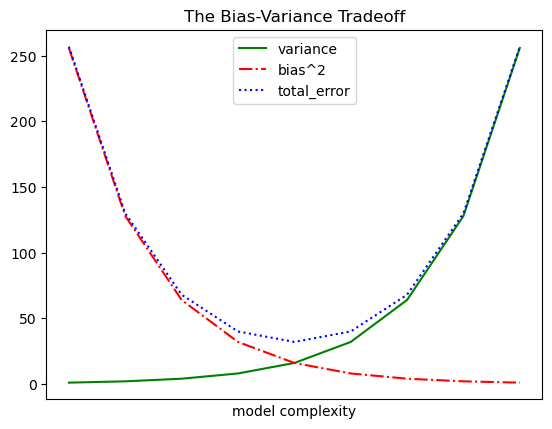

In [5]:
plt.plot(xs, variance, "g-", label="variance")        # linha verde sólida
plt.plot(xs, bias_squared, "r-.", label="bias^2")     # vermelha traço-e-ponto
plt.plot(xs, total_error, "b:", label="total_error")  # azul pontilhada

plt.legend(loc=9)
plt.xlabel("model complexity")
plt.xticks([])
plt.title("The Bias-Variance Tradeoff")
plt.show()

### Estilo rápido com string

O terceiro argumento (`"g-"`, `"r-."`, `"b:"`) é um atalho de **uma letra**: cor + estilo do traço, colados.

| String | Cor | Traço |
| --- | --- | --- |
| `"g-"` | verde (`g`) | sólido (`-`) |
| `"r-."` | vermelho (`r`) | traço-e-ponto (`-.`) |
| `"b:"` | azul (`b`) | pontilhado (`:`) |

Isso é o mesmo que escrever `color="green", linestyle="solid"`, só que mais curto.

### A legenda "de graça"

`plt.legend(loc=9)` só funciona porque **cada linha recebeu um `label=`** — sem ele o Matplotlib não teria o que escrever. `loc=9` posiciona no **topo central** (é o atalho de `loc="upper center"`).

### Rótulos e limpeza do eixo x

- `plt.xlabel("model complexity")` nomeia o eixo horizontal: quanto mais complexo o modelo, mais à direita.
- `plt.xticks([])` com lista vazia **apaga as marcações** do eixo x. Aqui faz sentido, porque 0 a 8 não são medidas reais, só posições.
- Repare que **não existe `ylabel`**. É de propósito: com a legenda, diz-se em que unidade a linha está.
- `plt.show()` é o que **abre a janela** com o gráfico. Antes disso, todas as chamadas de `plt.*` só estavam desenhando.

## O que o gráfico mostra

A linha `total_error` forma um **U**:

- À esquerda, o **viés domina** (modelo simplificado demais → erro 257)
- À direita, a **variância domina** (modelo complexo demais → erro 257)
- O mínimo está em `xs = 4`, com erro **32** — o **ponto ideal de complexidade**

Os extremos são idênticos (1 + 256), então ==não adianta modelo nem muito simples nem muito complexo==: o equilíbrio está no meio.

## Armadilhas comuns

- **Trocar a ordem dos argumentos em `plt.plot`** → o primeiro é *sempre* o eixo x. `plt.plot(variance, xs)` desenha a linha deitada.
- **Listas de tamanhos diferentes em `zip`** → o gráfico sai truncado, sem erro nem aviso.
- **Colocar o `label=` fora do `plt.plot`** → a legenda fica vazia.
- **Usar `plt.xticks([])` e depois querer os números** → eles somem. Para manter as marcas sem os números: `plt.xticks(xs, [])`.
- **A ordem das chamadas importa** → a última linha plotada fica por cima na sobreposição.